<a href="https://colab.research.google.com/github/amallindask/data-science-2026/blob/main/Pertemuan12_Amallinda_250401020003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IDENTITAS MAHASISWA

---
Nama : Amallinda Sekar Kinasih

---

NIM : 250401020003

---

Kelas : IF403


Contoh transaksi:
[[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi : 50
    Produk  Frekuensi
4    Selai         26
5      Teh         23
2  Mentega         21
7    Telur         18
0     Keju         17
1     Roti         16
3     Kopi         16
6     Susu         16
8     Gula         16
9   Sereal          9


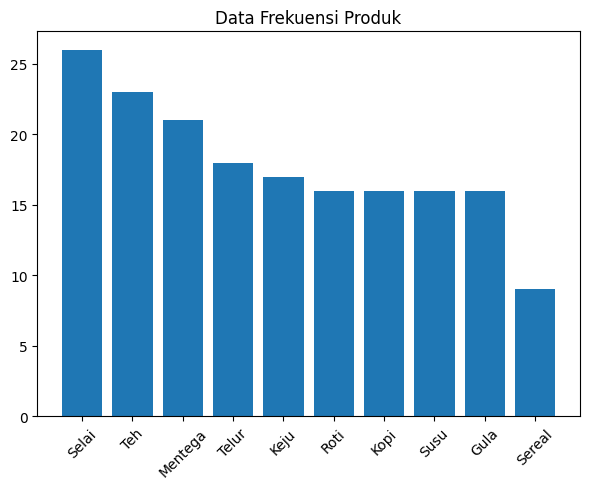

In [6]:
# LANGKAH 1 GENERATE DAN EKSPLORASI DATASET TRANSAKSI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Membuat 50 transaksi
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2,6)
    transaksi.append(
        list(np.random.choice(produk,
                              n_item,
                              replace=False))
    )

# Menambahkan pola bahwa Roti sering dibeli bersama Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:")
print(transaksi[:3])

print("Jumlah transaksi :", len(transaksi))

from collections import Counter
counter = Counter()
for t in transaksi:
    counter.update(t)

freq = pd.DataFrame(counter.items(), columns=['Produk','Frekuensi'])
freq = freq.sort_values('Frekuensi', ascending=False)

print(freq)

plt.figure(figsize=(7,5))
plt.bar(freq['Produk'], freq['Frekuensi'])
plt.xticks(rotation=45)
plt.title("Data Frekuensi Produk")
plt.show()

In [3]:
# LANGKAH 2 ONE-HOT ENCODING TRANSAKSI

!pip install mlxtend

In [4]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(te_array,
                  columns=te.columns_)

df.head()

,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


In [ ]:
# LANGKAH 3 MENCARI FREQUENT ITEMSET DENGAN APRIORI
import warnings
warnings.filterwarnings("ignore")
from mlxtend.frequent_patterns import apriori

for ms in [0.05,0.10,0.20]:

    freq = apriori(df,
                   min_support=ms,
                   use_colnames=True)

    print(f"min_support={ms}: {len(freq)} itemset ditemukan")

freq_items = apriori(df,min_support=0.10,
                     use_colnames=True)

freq_items = freq_items.sort_values(
    by='support',
    ascending=False
)

#freq_items.head(10)
#print(freq_items.head(10))
display(freq_items.head(10))

In [12]:
# LANGKAH 4 BENTUK DAN SARING ATURAN ASOSIASI

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[rules['lift'] > 1]

rules = rules.sort_values(
    by='lift',
    ascending=False
)

rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head(10)

,antecedents,consequents,support,confidence,lift
10,"(Teh, Keju)",(Telur),0.12,0.857143,2.380952
14,"(Mentega, Selai)",(Kopi),0.10,0.625000,1.953125
11,"(Roti, Gula)",(Selai),0.10,1.000000,1.923077
7,(Sereal),(Mentega),0.14,0.777778,1.851852
8,"(Telur, Teh)",(Keju),0.12,0.600000,1.764706
15,"(Kopi, Selai)",(Mentega),0.10,0.714286,1.700680
9,"(Telur, Keju)",(Teh),0.12,0.750000,1.630435
12,"(Gula, Selai)",(Roti),0.10,0.500000,1.562500
13,"(Mentega, Kopi)",(Selai),0.10,0.714286,1.373626
1,(Roti),(Selai),0.22,0.687500,1.322115


In [13]:
# LANGKAH 5 REKOMENDER SEDERHANA DENGAN CONTENT-BASED FILTERING

from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': [
        'Bakery',
        'Bakery',
        'Dairy',
        'Bakery',
        'Dairy',
        'Dairy',
        'Minuman',
        'Bumbu',
        'Minuman',
        'Dairy'
    ]
})

fitur = pd.get_dummies(katalog['kategori'])

sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):

    idx = katalog.index[
        katalog['produk']==nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))

    skor = sorted(
        skor,
        key=lambda x:x[1],
        reverse=True
    )

    skor = [s for s in skor if s[0]!=idx][:top_n]

    return katalog.iloc[
        [i for i,_ in skor]
    ]['produk'].tolist()

print("Mirip dengan Roti:")
print(rekomendasi_serupa("Roti"))

Mirip dengan Roti:
['Selai', 'Sereal', 'Susu']


In [14]:
# LANGKAH 6 MEMBANDINGKAN KEDUA PENDEKATAN

produk_target = "Roti"

rules_terkait = rules[
    rules['antecedents'].apply(
        lambda x: produk_target in x
    )
]

print("Rekomendasi dari Association Rules")
print(
    rules_terkait[
        ['consequents','lift']
    ].head()
)

print()

print("Rekomendasi dari Content Based")

print(rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content Based
['Selai', 'Sereal', 'Susu']


#KESIMPULAN
###Berdasarkan hasil yang diperoleh, kedua metode memberikan rekomendasi dengan pendekatan yang berbeda. **Association Rules** merekomendasikan produk berdasarkan kebiasaan pelanggan saat berbelanja, sehingga produk yang disarankan adalah produk yang sering dibeli secara bersamaan dalam satu transaksi. Sementara itu, **Content-Based Filtering** memberikan rekomendasi berdasarkan kemiripan karakteristik atau kategori produk, sehingga produk yang memiliki kategori yang sama akan dianggap saling berkaitan. Karena menggunakan dasar yang berbeda, hasil rekomendasi dari kedua metode tidak selalu sama.

###Association Rules lebih efektif apabila tersedia data riwayat transaksi yang banyak, sedangkan Content-Based Filtering lebih cocok digunakan ketika informasi mengenai karakteristik produk sudah lengkap, meskipun data transaksi masih terbatas. Oleh karena itu, menggabungkan kedua metode dalam sebuah sistem rekomendasi hibrida dapat menghasilkan rekomendasi yang lebih relevan karena mempertimbangkan pola pembelian pelanggan sekaligus kesamaan antarproduk.
